In [1]:
!pip install geocube rasterio

  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.7 MB/s  0:00:00
Using cached appdirs-1.4.4-py2.py3-none-any.whl (9.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [geocube]m5/6 [geocube]y]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from geocube.api.core import make_geocube
import geopandas as gpd

file_path = '/Users/zohuruzzamanjyoti/Documents/WeatherData/ASOS/processed_parquet/1951.parquet'
df = pd.read_parquet(file_path)

# Prepare the GeoDataFrame
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# List of columns to visualize
precip_cols = ["precip_1_depth_mm", "precip_2_depth_mm", "precip_1_period_hrs", "precip_2_period_hrs"]

# Create a raster grid from the points
# Note: resolution can be adjusted based on data density
out_grid = make_geocube(
    vector_data=gdf,
    measurements=precip_cols,
    resolution=(-0.5, 0.5)  # 0.5 degree resolution
)

# Plotting the results using matplotlib via xarray (which uses raster-like structures)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(precip_cols):
    out_grid[col].plot(ax=axes[i], cmap="viridis")
    axes[i].set_title(f"Spatial Distribution of {col}")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Aggregating data by station location...
Rasterizing 2614 unique stations...


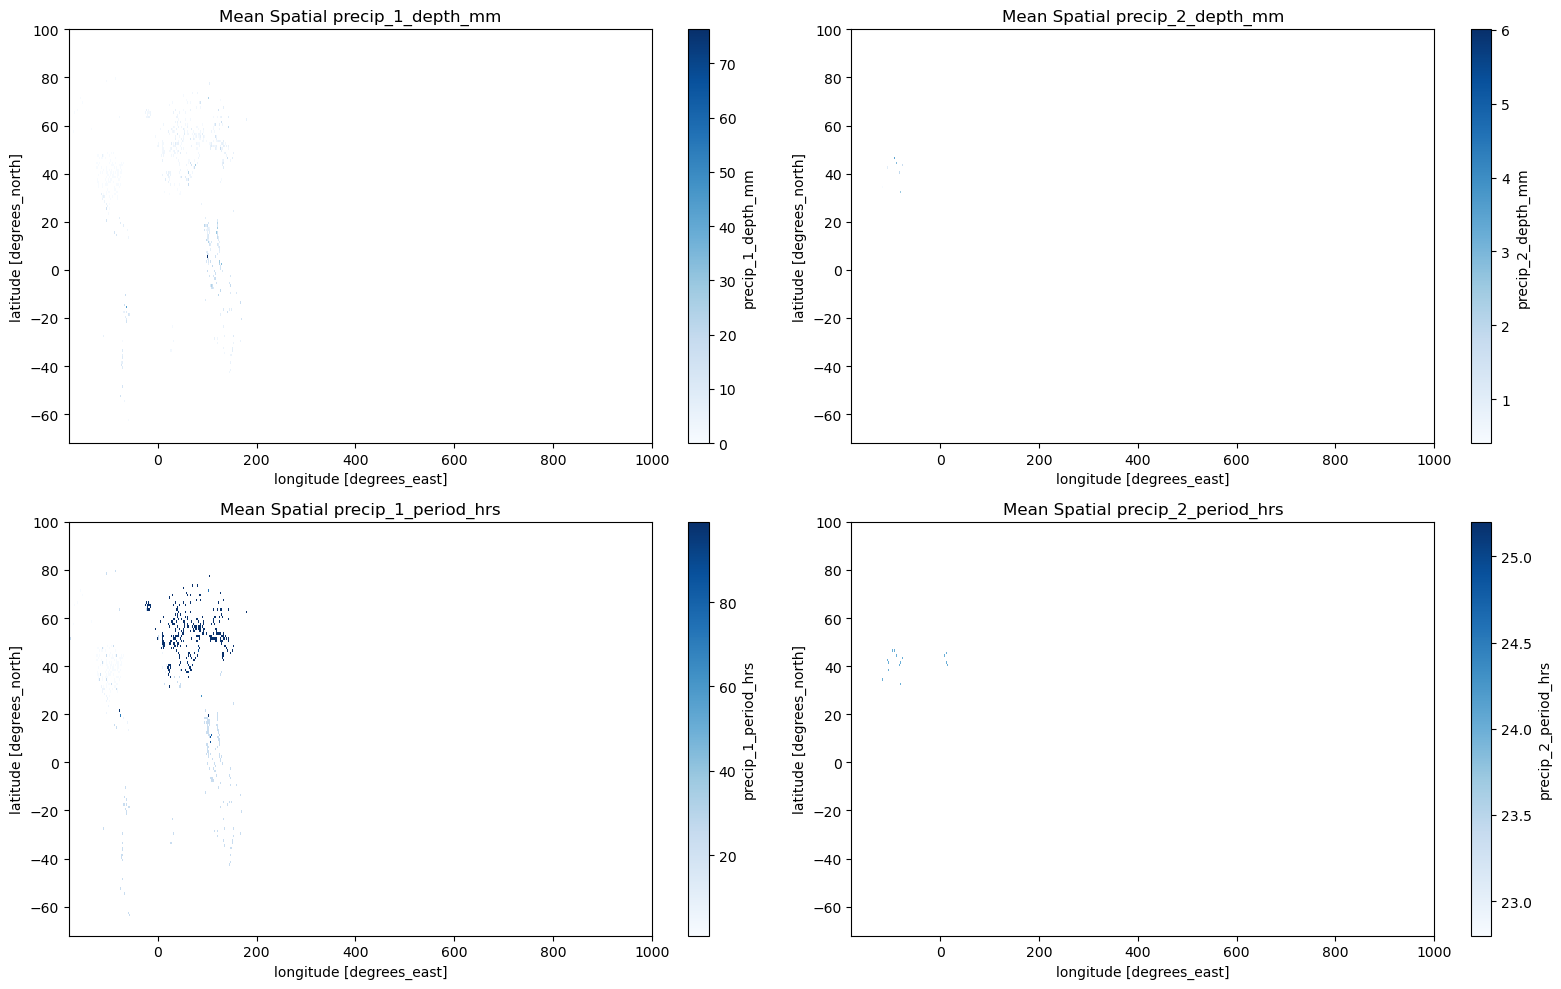

In [3]:
# OPTIMIZATION: Aggregate by station to reduce 9M rows to unique locations
print("Aggregating data by station location...")
precip_cols = ["precip_1_depth_mm", "precip_2_depth_mm", "precip_1_period_hrs", "precip_2_period_hrs"]

df_station = df.groupby(['latitude', 'longitude'])[precip_cols].mean().reset_index()

# Prepare the GeoDataFrame with aggregated data
gdf = gpd.GeoDataFrame(
    df_station, 
    geometry=gpd.points_from_xy(df_station.longitude, df_station.latitude),
    crs="EPSG:4326"
)

print(f"Rasterizing {len(gdf)} unique stations...")

# Create a raster grid
# A resolution of 1.0 degree is much faster for a quick look at the USA
out_grid = make_geocube(
    vector_data=gdf,
    measurements=precip_cols,
    resolution=(-1.0, 1.0) 
)

# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(precip_cols):
    out_grid[col].plot(ax=axes[i], cmap="Blues")
    axes[i].set_title(f"Mean Spatial {col}")

plt.tight_layout()
plt.show()

In [5]:
# Filter to USA bounding box roughly: Lat [24, 50], Lon [-125, -66]
df_usa = df[(df.latitude >= 24) & (df.latitude <= 50) & (df.longitude >= -125) & (df.longitude <= -66)]

print(f"Aggregating {len(df_usa)} USA records...")
precip_cols = ["precip_1_depth_mm", "precip_2_depth_mm", "precip_1_period_hrs", "precip_2_period_hrs"]
df_station = df_usa.groupby(['latitude', 'longitude'])[precip_cols].mean().reset_index()

gdf = gpd.GeoDataFrame(
    df_station, 
    geometry=gpd.points_from_xy(df_station.longitude, df_station.latitude),
    crs="EPSG:4326"
)

# Load a world map for context
world = gpd.read_file(gpd.datasets.get_path('nhttps://www.naturalearthdata.com/downloads/110m-cultural-vectors/.'))
usa_boundary = world[world.name == "United States of America"]

print(f"Rasterizing {len(gdf)} unique USA stations...")
out_grid = make_geocube(
    vector_data=gdf,
    measurements=precip_cols,
    resolution=(-0.5, 0.5) 
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(precip_cols):
    # Plot boundary
    usa_boundary.plot(ax=axes[i], color='white', edgecolor='black')
    # Plot raster
    out_grid[col].plot(ax=axes[i], cmap="Blues", alpha=0.8)
    axes[i].set_title(f"USA Spatial {col}")
    axes[i].set_xlim([-130, -65])
    axes[i].set_ylim([23, 50])

plt.tight_layout()
plt.show()

Aggregating 5580123 USA records...


AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. New sample datasets are now available in the geodatasets package (https://geodatasets.readthedocs.io/en/latest/)

In [18]:
import pandas as pd

# Load the parquet file available in the directory
file_path = r'asos_1min_2020_parquet/64060KALW202004.parquet'
df = pd.read_parquet(file_path)

# Display the first few rows and summary information
print(f"Dataset Shape: {df.shape}")
display(df.head())
display(df.info())

Dataset Shape: (40767, 6)


,wban,icao,datetime_utc,precip_id,precip_1min_in,temp_F
0,24160,KALW,2020-04-01 08:00:00,NP,0.0,28.742
1,24160,KALW,2020-04-01 08:01:00,NP,0.0,28.743
2,24160,KALW,2020-04-01 08:02:00,NP,0.0,28.743
3,24160,KALW,2020-04-01 08:03:00,NP,0.0,28.743
4,24160,KALW,2020-04-01 08:04:00,NP,0.0,28.743


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40767 entries, 0 to 40766
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   wban            40767 non-null  object        
 1   icao            40767 non-null  object        
 2   datetime_utc    40767 non-null  datetime64[ns]
 3   precip_id       40767 non-null  object        
 4   precip_1min_in  40704 non-null  float64       
 5   temp_F          40767 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 1.9+ MB


None

In [17]:
import pandas as pd

# Load your processed year
df = pd.read_parquet("processed_parquet/1974.parquet")

# Convert string dates to Datetime
df['date'] = pd.to_datetime(df['date'])

# Calculate time difference
df = df.sort_values(by=['station_id', 'date'])
df['minutes_since_last_reading'] = df.groupby('station_id')['date'].diff().dt.total_seconds() / 60

# STRICT FILTER: Greater than 0 minutes, but less than 50 minutes
true_sub_hourly_df = df[(df['minutes_since_last_reading'] > 0) & (df['minutes_since_last_reading'] < 50)]

print(f"Found {len(true_sub_hourly_df):,} true sub-hourly special reports!")
print(true_sub_hourly_df[['station_name', 'date', 'minutes_since_last_reading', 'temperature_celsius']].head(20))

Found 3,317,710 true sub-hourly special reports!
         station_name                date  minutes_since_last_reading  \
18707549   ANDOYA, NO 1974-01-01 06:00:00                        10.0   
18707557   ANDOYA, NO 1974-01-01 13:00:00                        10.0   
18707559   ANDOYA, NO 1974-01-01 15:00:00                        10.0   
18707563   ANDOYA, NO 1974-01-01 18:00:00                        10.0   
18707567   ANDOYA, NO 1974-01-01 21:00:00                        10.0   
18707574   ANDOYA, NO 1974-01-02 03:00:00                        10.0   
18707577   ANDOYA, NO 1974-01-02 06:00:00                        10.0   
18707581   ANDOYA, NO 1974-01-02 09:00:00                        10.0   
18707584   ANDOYA, NO 1974-01-02 12:00:00                        10.0   
18707588   ANDOYA, NO 1974-01-02 15:00:00                        10.0   
18707590   ANDOYA, NO 1974-01-02 18:00:00                        10.0   
18707594   ANDOYA, NO 1974-01-02 21:00:00                        10.0   
18